<a href="https://colab.research.google.com/github/NandhithaMilkuri/Nandhitha1352ADM/blob/main/StockMarketAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

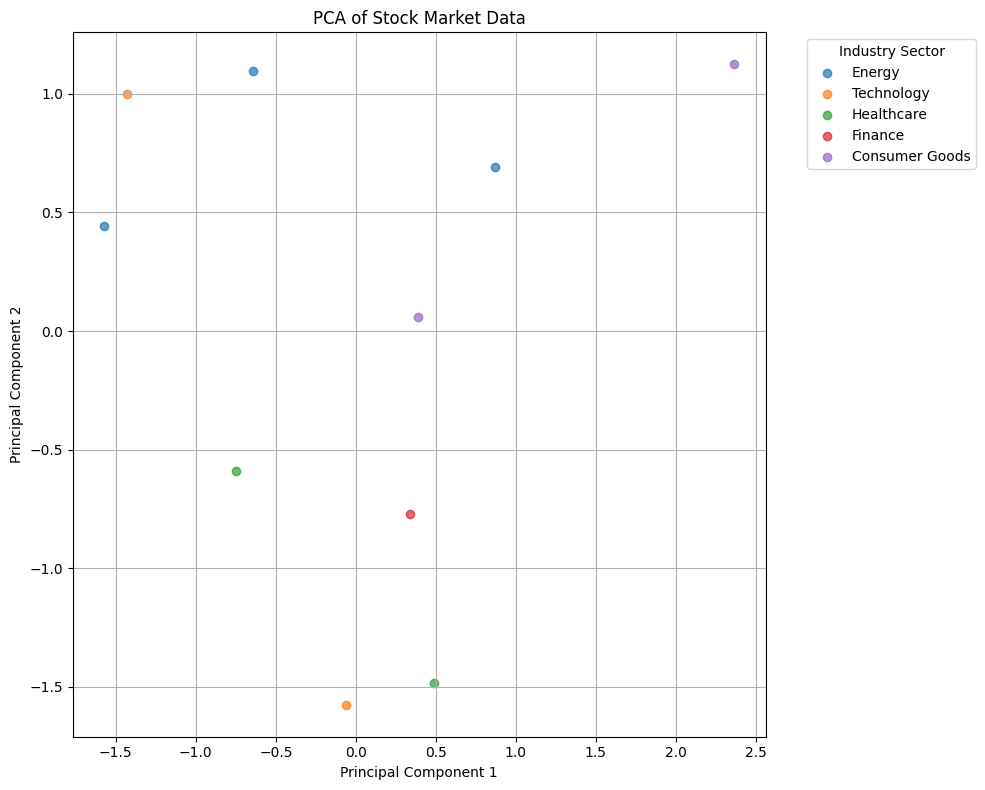

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Stock.csv')

data = df[['Stock_Price', 'Trading_Volume', 'Moving_Avg']]
industry_sectors = df['Industry_Sector']

data = data.fillna(data.mean())
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(data_scaled)

pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Industry_Sector'] = industry_sectors

plt.figure(figsize=(10, 8))
for sector in pca_df['Industry_Sector'].unique():
    sector_data = pca_df[pca_df['Industry_Sector'] == sector]
    plt.scatter(sector_data['PC1'], sector_data['PC2'], label=sector, alpha=0.7)

plt.title('PCA of Stock Market Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Industry Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()
